1. Data analysis

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Motorisation study — config
# ============================================================

INPUT_CSV = Path("input/Donnees-sur-le-parc-de-vehicules-au-niveau-communal.2025-09.csv")
SEP = ";"
CHUNKSIZE = 200_000

# CdA La Rochelle (28 communes — INSEE codes)
COMMUNES_INSEE = [
    "17010", "17028", "17059", "17094", "17109", "17136", "17142", "17153",
    "17190", "17193", "17194", "17200", "17222", "17245", "17264", "17274",
    "17291", "17300", "17315", "17373", "17391", "17407", "17413", "17414",
    "17420", "17443", "17466", "17483",
]

CATEGORY_KEEP = "VP"      # Passenger cars
FLEET_COL = "PARC_2022"   # Column used for vehicle counts (2022)

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_CSV.resolve()}")

In [3]:
# ============================================================
# Load + filter (VP, CdA communes)
# ============================================================

def load_filtered_vp_fleet(
    csv_path: Path,
    communes: list[str],
    fleet_col: str,
    category_keep: str = "VP",
    sep: str = ";",
    chunksize: int = 200_000,
) -> pd.DataFrame:
    # Read header only (to validate columns)
    cols = pd.read_csv(csv_path, sep=sep, nrows=0).columns.tolist()

    required = {"COMMUNE_CODE", "COMMUNE_NOM", "CATEGORIE", "CARBURANT", "CRIT_AIR", fleet_col}
    missing = required - set(cols)
    if missing:
        raise ValueError(
            f"Missing columns in CSV: {sorted(missing)}\n"
            f"Available columns (sample): {cols[:40]}"
        )

    usecols = ["COMMUNE_CODE", "COMMUNE_NOM", "CATEGORIE", "CARBURANT", "CRIT_AIR", fleet_col]

    parts = []
    for chunk in pd.read_csv(
        csv_path,
        sep=sep,
        dtype=str,
        usecols=usecols,
        chunksize=chunksize,
        low_memory=False,
    ):
        mask = chunk["COMMUNE_CODE"].isin(communes) & (chunk["CATEGORIE"] == category_keep)
        sub = chunk.loc[mask].copy()
        if not sub.empty:
            parts.append(sub)

    df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=usecols)

    # Numeric clean
    df[fleet_col] = pd.to_numeric(df[fleet_col], errors="coerce").fillna(0)

    return df


df_vp = load_filtered_vp_fleet(
    csv_path=INPUT_CSV,
    communes=COMMUNES_INSEE,
    fleet_col=FLEET_COL,
    category_keep=CATEGORY_KEEP,
    sep=SEP,
    chunksize=CHUNKSIZE,
)

print("[INFO] Filtered VP fleet shape:", df_vp.shape)
df_vp.head()

[INFO] Filtered VP fleet shape: (863, 6)


,COMMUNE_CODE,COMMUNE_NOM,CARBURANT,CRIT_AIR,CATEGORIE,PARC_2022
0,17010,Angoulins,Essence HR,Crit'Air 1,VP,18
1,17010,Angoulins,Essence HNR,Crit'Air 1,VP,59
2,17010,Angoulins,Gaz,Crit'Air 1,VP,13
3,17010,Angoulins,Diesel,Crit'Air 2,VP,20
4,17010,Angoulins,Diesel,Crit'Air 2,VP,715


In [4]:
# ============================================================
# Aggregation: fuel x Crit'Air
# ============================================================

df_fuel_critair = (
    df_vp
    .groupby(["CARBURANT", "CRIT_AIR"], dropna=False)[FLEET_COL]
    .sum()
    .reset_index(name="NB_VEHICULES")
)

# Keep only existing combos
df_fuel_critair = df_fuel_critair[df_fuel_critair["NB_VEHICULES"] > 0].copy()

print("[INFO] Number of (fuel, Crit'Air) combos:", len(df_fuel_critair))
df_fuel_critair.sort_values("NB_VEHICULES", ascending=False).head(15)

[INFO] Number of (fuel, Crit'Air) combos: 19


,CARBURANT,CRIT_AIR,NB_VEHICULES
8,Essence,Crit'Air 1,31735
0,Diesel,Crit'Air 2,29576
1,Diesel,Crit'Air 3,14715
9,Essence,Crit'Air 2,7594
10,Essence,Crit'Air 3,7504
2,Diesel,Crit'Air 4,6125
12,Essence HNR,Crit'Air 1,3091
11,Essence,Non classé,2144
7,Electrique,Crit'Air E,1573
3,Diesel,Crit'Air 5,1299


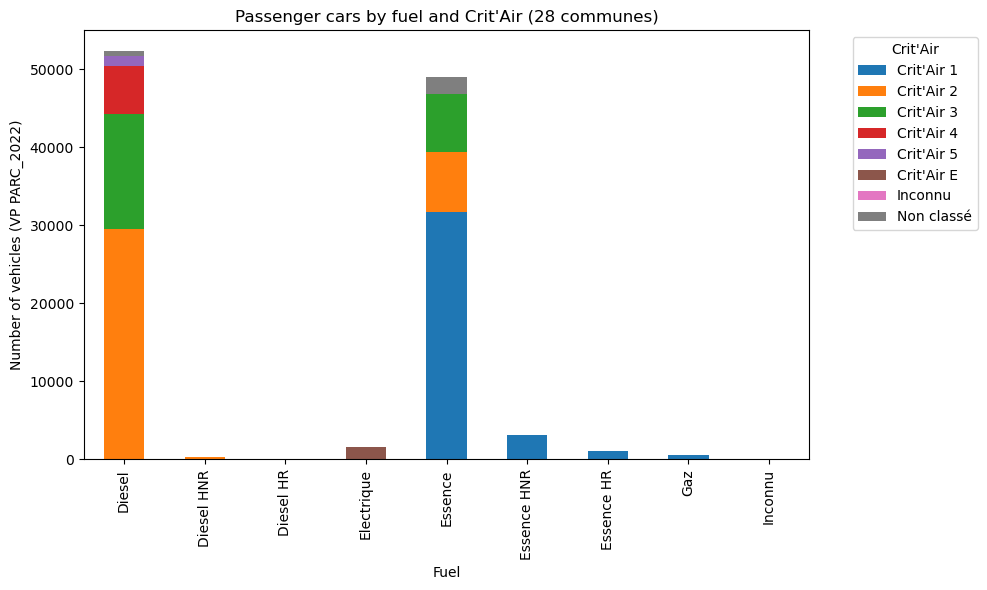

In [ ]:
# ============================================================
# stacked bar plot (fuel x Crit'Air)
# ============================================================

pivot = (
    df_fuel_critair
    .pivot(index="CARBURANT", columns="CRIT_AIR", values="NB_VEHICULES")
    .fillna(0)
)

pivot.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.xlabel("Fuel")
plt.ylabel(f"Number of vehicles ({CATEGORY_KEEP} {FLEET_COL})")
plt.title("Passenger cars by fuel and Crit'Air (28 communes)")
plt.legend(title="Crit'Air", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Mapping to SUMO emissionClass (single class per fuel/Crit'Air combo)
# ============================================================

def _critair_code(x):
    """Return 'E' (electric), int (1..5), or None."""
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if "crit" in s and ("e" in s or "é" in s):
        return "E"
    m = re.search(r"(\d+)", s)
    if m:
        return int(m.group(1))
    return None

def _is_unclassified(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return ("non class" in s) or (s == "") or (s == "nan")

def _fuel_family(label: str):
    """Return a coarse fuel family."""
    s = ("" if pd.isna(label) else str(label)).lower()
    if "elect" in s:
        return "electric"
    if "diesel" in s:
        return "diesel"
    if "essence" in s:
        return "petrol"
    if "gaz" in s:
        return "gas"
    return "petrol"

def _euro_from_critair(family: str, crit):
    """
    Approximate Euro class from Crit'Air (passenger cars).
    NOTE: Crit'Air 1 official wording for gas/PHEV is not Euro-specific -> proxy Euro-6ab.
    """
    if crit is None:
        return "Euro-1"

    if crit == "E":
        return None

    if crit == 1:
        return "Euro-6ab"  # proxy assumption (recent vehicles)

    if family == "diesel":
        return {2: "Euro-6ab", 3: "Euro-4", 4: "Euro-3", 5: "Euro-2"}.get(crit, "Euro-1")

    # petrol/others
    return {2: "Euro-4", 3: "Euro-3"}.get(crit, "Euro-1")

def _to_euro6_for_gas(euro: str):
    # HBEFA naming for LPG/CNG often uses "Euro-6" (not Euro-6ab)
    if euro and euro.startswith("Euro-6"):
        return "Euro-6"
    return euro

def map_to_sumo_emission_class_single(fuel_label, critair_label):
    """
    Return (sumo_emissionClass, note) using ONE class per combo (no thermal/electric split).
    """
    fuel = "" if pd.isna(fuel_label) else str(fuel_label).strip()
    fuel_l = fuel.lower()

    crit = _critair_code(critair_label)
    fam = _fuel_family(fuel_l)
    euro = _euro_from_critair(fam, crit)

    # Electric
    if fam == "electric" or crit == "E":
        return ("HBEFA4/PC_BEV", "Battery electric vehicle (BEV)")

    # Unknown / unclassified
    if ("inconnu" in fuel_l) or _is_unclassified(critair_label):
        if fam == "diesel":
            return ("HBEFA4/PC_diesel_Euro-1", "Fallback diesel (unclassified/unknown)")
        if fam == "gas":
            return ("HBEFA4/PC_LPG_petrol_Euro-1_(LPG)", "Fallback gas -> assumed LPG")
        return ("HBEFA4/PC_petrol_Euro-1", "Fallback petrol (unclassified/unknown)")

    # Plug-in hybrid (HR): single class
    if (" hr" in f" {fuel_l}") and ("hnr" not in fuel_l):
        if fam == "diesel":
            return (f"HBEFA4/PC_PHEV_diesel_{euro}", "PHEV diesel (Euro proxy if Crit'Air 1)")
        return (f"HBEFA4/PC_PHEV_petrol_{euro}", "PHEV petrol (Euro proxy if Crit'Air 1)")

    # Non plug-in hybrid (HNR): approximate as conventional
    if "hnr" in fuel_l:
        if fam == "diesel":
            return (f"HBEFA4/PC_diesel_{euro}", "Diesel (HNR approximated as conventional diesel)")
        if fam == "gas":
            euro_g = _to_euro6_for_gas(euro)
            return (f"HBEFA4/PC_LPG_petrol_{euro_g}_(LPG)", "Gas (HNR approx) -> assumed LPG")
        return (f"HBEFA4/PC_petrol_{euro}", "Petrol (HNR approximated as conventional petrol)")

    # Conventional fuels
    if fam == "diesel":
        return (f"HBEFA4/PC_diesel_{euro}", "Diesel")
    if fam == "gas":
        euro_g = _to_euro6_for_gas(euro)
        return (f"HBEFA4/PC_LPG_petrol_{euro_g}_(LPG)", "Gas -> assumed LPG (Euro proxy if Crit'Air 1)")
    return (f"HBEFA4/PC_petrol_{euro}", "Petrol")


# Build mapping table for existing (fuel, Crit'Air) combos
rows = []
for _, r in df_fuel_critair.iterrows():
    em_cls, note = map_to_sumo_emission_class_single(r["CARBURANT"], r["CRIT_AIR"])
    rows.append({
        "CARBURANT": r["CARBURANT"],
        "CRIT_AIR": r["CRIT_AIR"],
        "NB_VEHICULES": r["NB_VEHICULES"],
        "emissionClass_sumo": em_cls,
        "note": note,
    })

df_map_sumo = pd.DataFrame(rows).sort_values(["CARBURANT", "CRIT_AIR"]).reset_index(drop=True)
df_map_sumo.head(20)

,CARBURANT,CRIT_AIR,NB_VEHICULES,emissionClass_sumo,note
0,Diesel,Crit'Air 2,29576,HBEFA4/PC_diesel_Euro-6ab,Diesel
1,Diesel,Crit'Air 3,14715,HBEFA4/PC_diesel_Euro-4,Diesel
2,Diesel,Crit'Air 4,6125,HBEFA4/PC_diesel_Euro-3,Diesel
3,Diesel,Crit'Air 5,1299,HBEFA4/PC_diesel_Euro-2,Diesel
4,Diesel,Non classé,633,HBEFA4/PC_diesel_Euro-1,Fallback diesel (unclassified/unknown)
5,Diesel HNR,Crit'Air 2,357,HBEFA4/PC_diesel_Euro-6ab,Diesel (HNR approximated as conventional diesel)
6,Diesel HR,Crit'Air 1,36,HBEFA4/PC_PHEV_diesel_Euro-6ab,PHEV diesel (Euro proxy if Crit'Air 1)
7,Electrique,Crit'Air E,1573,HBEFA4/PC_BEV,Battery electric vehicle (BEV)
8,Essence,Crit'Air 1,31735,HBEFA4/PC_petrol_Euro-6ab,Petrol
9,Essence,Crit'Air 2,7594,HBEFA4/PC_petrol_Euro-4,Petrol


In [7]:
# ============================================================
# Final proportions: emissionClass_sumo share (%)
# ============================================================

df_prop = (
    df_map_sumo
    .groupby("emissionClass_sumo", as_index=False)["NB_VEHICULES"]
    .sum()
)

total = df_prop["NB_VEHICULES"].sum()
df_prop["PART_%"] = (df_prop["NB_VEHICULES"] / total) * 100
df_prop = df_prop.sort_values("NB_VEHICULES", ascending=False).reset_index(drop=True)

print("[INFO] Total vehicles:", int(total))
df_prop

[INFO] Total vehicles: 108142


,emissionClass_sumo,NB_VEHICULES,PART_%
0,HBEFA4/PC_petrol_Euro-6ab,34826,32.203954
1,HBEFA4/PC_diesel_Euro-6ab,29933,27.679348
2,HBEFA4/PC_diesel_Euro-4,14715,13.607109
3,HBEFA4/PC_petrol_Euro-4,7617,7.043517
4,HBEFA4/PC_petrol_Euro-3,7504,6.939025
5,HBEFA4/PC_diesel_Euro-3,6125,5.663849
6,HBEFA4/PC_petrol_Euro-1,2153,1.990901
7,HBEFA4/PC_BEV,1573,1.454569
8,HBEFA4/PC_diesel_Euro-2,1299,1.201198
9,HBEFA4/PC_PHEV_petrol_Euro-6ab,1103,1.019955


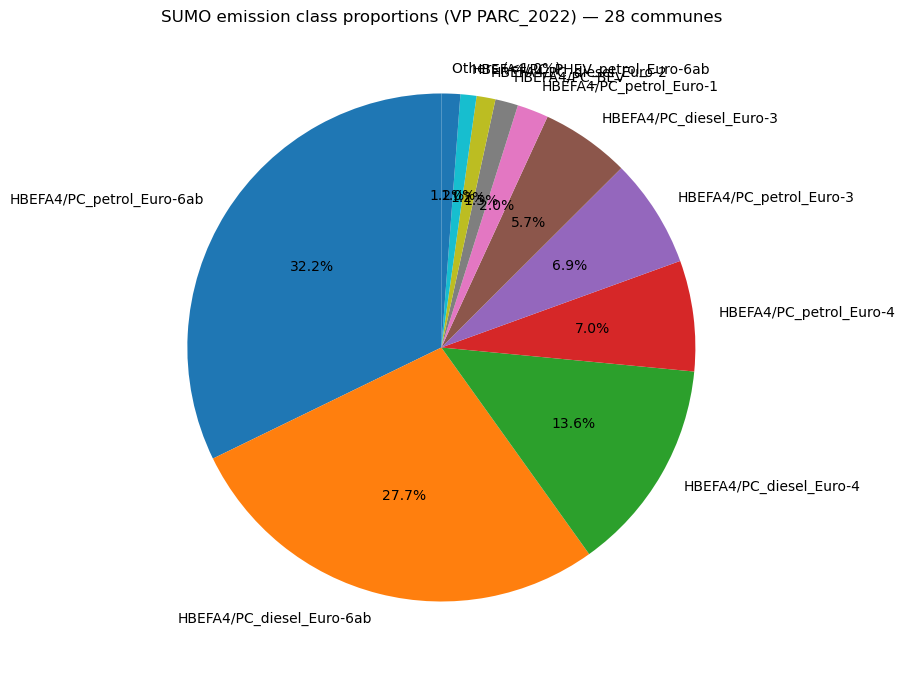

In [8]:
# ============================================================
# Optional: pie chart (group small shares into "Others")
# ============================================================

SEUIL_PCT = 1.0  # group everything below 1% as "Others"

df_pie = df_prop.copy()
mask_small = df_pie["PART_%"] < SEUIL_PCT

if mask_small.any():
    big = df_pie.loc[~mask_small, ["emissionClass_sumo", "NB_VEHICULES"]].copy()
    others_nb = df_pie.loc[mask_small, "NB_VEHICULES"].sum()
    df_pie2 = pd.concat(
        [big, pd.DataFrame([{"emissionClass_sumo": f"Others (<{SEUIL_PCT}%)", "NB_VEHICULES": others_nb}])],
        ignore_index=True
    )
else:
    df_pie2 = df_pie[["emissionClass_sumo", "NB_VEHICULES"]].copy()

plt.figure(figsize=(9, 9))
plt.pie(
    df_pie2["NB_VEHICULES"],
    labels=df_pie2["emissionClass_sumo"],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
)
plt.title(f"SUMO emission class proportions ({CATEGORY_KEEP} {FLEET_COL}) — 28 communes")
plt.tight_layout()
plt.show()

2. Assign HBEFA4 emission classes to car users (add vTypes + vTypes refs)

In [9]:
import xml.etree.ElementTree as ET
from pathlib import Path
import hashlib
import math
import csv

# ============================================================
# Assign HBEFA4 emission classes to car users (add vTypes + vTypes refs)
# ============================================================

# ------------------------
# CONFIG
# ------------------------
INPUT_XML = Path("../4-trips/population_all.rou.xml")                 # input routes file
OUTPUT_XML = Path("population_all_with_vtypes.rou.xml")              # output routes file
OUTPUT_CSV = Path("person_to_emissionClass.csv")                     # mapping for post-processing

SEED = "fleet_exact_v1"          # change to get a different deterministic realisation
OVERWRITE_EXISTING = True        # overwrite vTypes attribute if already present

# Distribution in percent (must sum to 100.0)
DIST = [
    ("HBEFA4/PC_petrol_Euro-6ab",             26.99),
    ("HBEFA4/PC_diesel_Euro-6ab",             32.15),
    ("HBEFA4/PC_diesel_Euro-4",               15.23),
    ("HBEFA4/PC_petrol_Euro-4",                5.92),
    ("HBEFA4/PC_petrol_Euro-3",                6.43),
    ("HBEFA4/PC_diesel_Euro-3",                6.66),
    ("HBEFA4/PC_BEV",                          1.33),
    ("HBEFA4/PC_petrol_Euro-1",                1.89),
    ("HBEFA4/PC_PHEV_petrol_Euro-6ab_(P)",     0.62),
    ("HBEFA4/PC_LPG_petrol_Euro-6_(LPG)",      0.61),
    ("HBEFA4/PC_diesel_Euro-2",                1.41),
    ("HBEFA4/PC_diesel_Euro-1",                0.76),
]

VTYPE_PREFIX = "vt_hbefa4_"  # vType id prefix
# ------------------------


def hash_hex(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()


def make_vtype_id(emission_class: str) -> str:
    """Make an XML-friendly vType id from an emissionClass string."""
    safe = emission_class.replace("HBEFA4/", "")
    safe = safe.replace("/", "_").replace("-", "_").replace("(", "").replace(")", "")
    while "__" in safe:
        safe = safe.replace("__", "_")
    return VTYPE_PREFIX + safe


def is_car_mode(modes_value: str) -> bool:
    """
    personTrip@modes can be 'car' or 'car taxi' etc.
    We consider it car if 'car' appears as a token.
    """
    if not modes_value:
        return False
    tokens = modes_value.replace(",", " ").split()
    return "car" in tokens


def compute_exact_quotas(n: int, dist):
    """
    Return emissionClass -> count, with sum == n.
    Uses floor(n*p) + largest remainder method.
    """
    total = sum(p for _, p in dist)
    if abs(total - 100.0) > 1e-3:
        raise ValueError(f"Distribution must sum to 100%. Got: {total}")

    raw = []
    for cls, p in dist:
        exact = n * (p / 100.0)
        base = int(math.floor(exact))
        frac = exact - base
        raw.append((cls, base, frac))

    counts = {cls: base for cls, base, _ in raw}
    remaining = n - sum(counts.values())

    raw_sorted = sorted(raw, key=lambda x: (-x[2], x[0]))
    for i in range(remaining):
        counts[raw_sorted[i][0]] += 1

    assert sum(counts.values()) == n
    return counts


def ensure_vtypes(root, dist):
    """Insert missing <vType> definitions and return emissionClass -> vTypeId mapping."""
    existing_ids = set()
    for vt in root.findall("vType"):
        vid = vt.get("id")
        if vid:
            existing_ids.add(vid)

    mapping = {}
    insert_pos = 0
    inserted = 0

    for emission_class, _ in dist:
        vtype_id = make_vtype_id(emission_class)
        mapping[emission_class] = vtype_id

        if vtype_id in existing_ids:
            continue

        vt = ET.Element(
            "vType",
            {
                "id": vtype_id,
                "vClass": "passenger",
                "emissionClass": emission_class,
            },
        )
        root.insert(insert_pos, vt)
        insert_pos += 1
        inserted += 1

    return mapping, inserted


def indent(elem, level=0):
    """Simple pretty print for ElementTree XML."""
    i = "\n" + level * "  "
    if len(elem):
        if not elem.text or not elem.text.strip():
            elem.text = i + "  "
        for child in elem:
            indent(child, level + 1)
        if not elem.tail or not elem.tail.strip():
            elem.tail = i
    else:
        if level and (not elem.tail or not elem.tail.strip()):
            elem.tail = i


# ------------------------
# RUN
# ------------------------
tree = ET.parse(INPUT_XML)
root = tree.getroot()

# 1) Collect car users and their car personTrips
car_people = []
car_trips_by_person = {}

for person in root.findall("person"):
    pid = person.get("id")
    if not pid:
        continue

    car_trips = []
    for elem in list(person):
        if elem.tag == "personTrip" and is_car_mode(elem.get("modes", "")):
            car_trips.append(elem)

    if car_trips:
        car_people.append(pid)
        car_trips_by_person[pid] = car_trips

N = len(car_people)
if N == 0:
    print("[INFO] No personTrip with modes containing 'car'. Nothing to do.")
else:
    # 2) Exact quotas
    quotas = compute_exact_quotas(N, DIST)

    # 3) Ensure <vType> definitions exist
    em2vtype, inserted = ensure_vtypes(root, DIST)

    # 4) Deterministic order of people
    car_people_sorted = sorted(car_people, key=lambda pid: hash_hex(pid + "|" + SEED))

    # 5) Build assignment list according to quotas (stable shuffle)
    assignment_list = []
    for cls, _p in DIST:
        assignment_list.extend([cls] * quotas[cls])
    assignment_list = sorted(assignment_list, key=lambda cls: hash_hex(cls + "|" + SEED))

    assert len(assignment_list) == N

    # 6) Apply vTypes to ALL car personTrips for each person
    person_to_cls = {}
    for pid, cls in zip(car_people_sorted, assignment_list):
        person_to_cls[pid] = cls
        vtype_id = em2vtype[cls]
        for trip in car_trips_by_person[pid]:
            if OVERWRITE_EXISTING or (trip.get("vTypes") is None):
                trip.set("vTypes", vtype_id)

    # 7) Write XML + mapping CSV
    indent(root)
    tree.write(OUTPUT_XML, encoding="utf-8", xml_declaration=True)

    with OUTPUT_CSV.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["person_id", "emissionClass", "vTypeId"])
        for pid in sorted(person_to_cls.keys()):
            cls = person_to_cls[pid]
            w.writerow([pid, cls, em2vtype[cls]])

    print("[OK] DONE")
    print(f"[INFO] Car users: {N}")
    print(f"[INFO] vTypes inserted: {inserted}")
    print(f"[INFO] Output XML: {OUTPUT_XML}")
    print(f"[INFO] Output CSV: {OUTPUT_CSV}")

[OK] DONE
[INFO] Car users: 12869
[INFO] vTypes inserted: 12
[INFO] Output XML: population_all_with_vtypes.rou.xml
[INFO] Output CSV: person_to_emissionClass.csv
